In [2]:
# checking system info
import sys

# for running gradient descent
import numpy as np
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

# for bringing the data in from R
import pandas as pd

import learnQ as lq


(CVXPY) Apr 02 09:31:53 AM: Encountered unexpected exception importing solver DIFFCP:
ImportError('diffcp >= 1.0.15 is required')


In [2]:
print(sys.executable)

/Users/jseid1/venv311/bin/python


In [ ]:
# load weights and post-treatment data
w_sep = pd.read_csv('T_0=40_K=10_w_sep.csv').to_numpy()
w_cat = pd.read_csv('T_0=40_K=10_w_cat.csv').to_numpy()
w_avg = pd.read_csv('T_0=40_K=10_w_avg.csv').to_numpy()
model_t1 = pd.read_csv('T_0=40_K=10_model_t1.csv').to_numpy()

# split into treated and control
model_t1_treated = model_t1[0, :]    # (K,) — first row is treated unit
model_t1_control = model_t1[1:, :]   # (N-1, K) — remaining rows are controls

# predictions from each method
pred_sep = model_t1_control.T @ w_sep    # (K,)
pred_cat = model_t1_control.T @ w_cat
pred_avg = model_t1_control.T @ w_avg
pred_learnQ = test_covariate_matrix.numpy()@ Q_final @ w_final  # (K,)

# compare against truth
print("True treated outcome:  ", model_t1_treated.round(3))
print("learnQ prediction:     ", pred_learnQ.round(3))
print("SCM sep prediction:    ", pred_sep.round(3))
print("SCM cat prediction:    ", pred_cat.round(3))
print("SCM avg prediction:    ", pred_avg.round(3))

True treated outcome:   [4.556 4.556 4.556 4.556 4.556 4.556 4.556 4.556 4.556 4.556]
learnQ prediction:      [4.609 4.737 4.493 5.096 4.615 3.929 4.246 4.921 5.599 4.766]
SCM sep prediction:     [[4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]
 [4.146]]
SCM cat prediction:     [[4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]
 [4.269]]
SCM avg prediction:     [[4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]
 [4.538]]


## Toy Example

The treated unit covariates are not in the convex hull of the donor units. $Q$ modifies the donor units covariates to find a combination whose convex hull contains the donor unit.

With 2 outcomes and 2 donors, it is possible to embed into 2 dimensions and find an optimal solution. Does this work with (3, 3, 3)?

There are:  2  weights being estimated
LearnQ prediction:  [1. 1.]
Simplex Constraint pred:  [0.5 0.5]
Truth:  [1. 1.]
Original Covariates: 
 [[1. 0.]
 [0. 1.]]
Q_final: 
 [[-0.142  2.142]
 [ 1.287  0.713]]
Synthetic Covariates: 
 [[-0.14231309  2.14231574]
 [ 1.28659445  0.71340488]]
w_final: 
 [0.5 0.5]


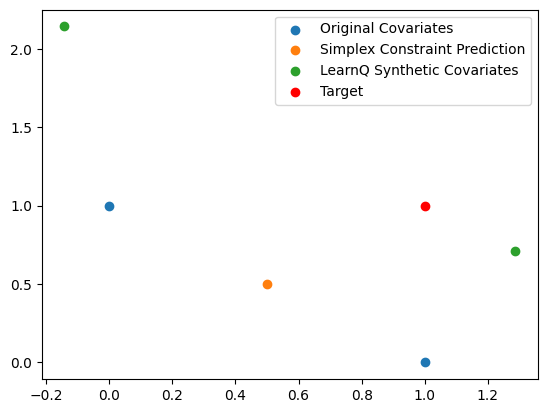

In [ ]:
torch.manual_seed(215)
import matplotlib.pyplot as plt

# Target and Covariates
d_1 = torch.tensor([1.0, 1.0], dtype=torch.float64)
Y_1 = torch.tensor([[1.0, 0.0], [0.0, 1.0]], dtype=torch.float64)
target_vectors = [d_1]
covariate_matrices = [Y_1]

# LearnQ optimization
Q_final, w_final = lq.learnQ(target_vectors, covariate_matrices, 2, 5000, 0, 1, False)

# Optimization over the simplex
target = d_1
covariates = Y_1
N_minus_1 = covariates.shape[1]
print("There are ",N_minus_1," weights being estimated")
w = cp.Variable(N_minus_1, nonneg=True) # Enforces w >= 0
constraints = [cp.sum(w) == 1]
obj = cp.Minimize(sum(cp.sum_squares(target - covariates @ w)))
prob = cp.Problem(obj, constraints)
prob.solve()

# Results
synth_covariates = (covariates @ Q_final).squeeze().numpy()
simplex_constraint_pred = (covariates @ w.value).detach().numpy().round(3)
print("LearnQ prediction: ", (covariates @ Q_final @ w_final).detach().numpy().round(3))
print("Simplex Constraint pred: ", simplex_constraint_pred)
print("Truth: ", target.numpy().round(3))
print("Original Covariates: \n", covariates.numpy().round(3))
print("Q_final: \n", Q_final.squeeze().round(3))
print("Synthetic Covariates: \n", synth_covariates)
print("w_final: \n", w_final.round(3))

# Plot
plt.scatter(Y_1[:, 0], Y_1[:, 1], label='Original Covariates')
plt.scatter(simplex_constraint_pred[0].item(), simplex_constraint_pred[1].item(), label='Simplex Constraint Prediction')
plt.scatter(synth_covariates[:, 0], synth_covariates[:, 1], label='LearnQ Synthetic Covariates')
plt.scatter(target[0].item(), target[1].item(), color='red', label='Target')
plt.legend()
plt.show()

Yes, we are able to find a perfect embedding in the cases (3,3,3) - (10,10,10). And the 

In [77]:
torch.manual_seed(215)
import matplotlib.pyplot as plt

# Target and Covariates
d_1 = torch.ones(10, dtype=torch.float64)
Y_1 = torch.eye(10, dtype=torch.float64) # identity matrix
target_vectors = [d_1]
covariate_matrices = [Y_1]

# LearnQ optimization
Q_final, w_final = lq.learnQ(target_vectors, covariate_matrices, 10, 5000, 0, 1, False)

# Optimization over the simplex
target = d_1
covariates = Y_1
N_minus_1 = covariates.shape[1]
print("There are ",N_minus_1," weights being estimated")
w = cp.Variable(N_minus_1, nonneg=True) # Enforces w >= 0
constraints = [cp.sum(w) == 1]
obj = cp.Minimize(sum(cp.sum_squares(target - covariates @ w)))
prob = cp.Problem(obj, constraints)
prob.solve()

# Results
synth_covariates = (covariates @ Q_final).squeeze().numpy()
simplex_constraint_pred = (covariates @ w.value).detach().numpy().round(3)
print("LearnQ prediction: ", (covariates @ Q_final @ w_final).detach().numpy().round(3))
print("Simplex Constraint pred: ", simplex_constraint_pred)
print("Truth: ", target.numpy().round(3))
print("Original Covariates: \n", covariates.numpy().round(3))
print("Q_final: \n", Q_final.squeeze().round(3))
print("Synthetic Covariates: \n", synth_covariates)
print("w_final: \n", w_final.round(3))

# Plot
# plt.scatter(Y_1[:, 0], Y_1[:, 1], label='Original Covariates')
# plt.scatter(simplex_constraint_pred[0].item(), simplex_constraint_pred[1].item(), label='Simplex Constraint Prediction')
# plt.scatter(synth_covariates[:, 0], synth_covariates[:, 1], label='LearnQ Synthetic Covariates')
# plt.scatter(target[0].item(), target[1].item(), color='red', label='Target')
# plt.legend()
# plt.show()

There are  10  weights being estimated
LearnQ prediction:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Simplex Constraint pred:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Truth:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Original Covariates: 
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Q_final: 
 [[ 1.847  0.813 -0.598  1.701  2.852  0.805  1.836 -0.007  0.159  0.593]
 [ 0.544  1.085  0.313  0.637  0.296 -1.085  2.508  2.522  2.101  1.079]
 [ 0.503  0.858  0.593  1.387  1.8    0.305  1.167  1.231  0.936  1.222]
 [ 1.109  0.343  1.787  2.187  2.14   0.174  1.537  0.331  0.014  0.378]
 [ 0.682  0.092 -0.073  2.105  0.886  2.351  0.838  1.742 -0.964  2.341]
 [ 0.75   1.476 -0.975  0.554  0.959  1.275  1.234  1.236 -0.146  3.637

In [13]:
# Data
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0], [3.0, 5.0]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 1.0], dtype=torch.float64)
Y_2 = torch.tensor([[9.0, 9.0], [2.0, 56.0]], dtype=torch.float64)

d_3 = torch.tensor([2.0, 7.0], dtype=torch.float64)
Y_3 = torch.tensor([[2.0, 1.0], [4.0, 5.0]], dtype=torch.float64)

d_4 = torch.tensor([8.0, 7.0], dtype=torch.float64)
Y_4 = torch.tensor([[6.0, 7.0], [1.0, 9.0]], dtype=torch.float64)




target_vectors = [d_1, d_2, d_3]
covariate_matrices = [Y_1, Y_2, Y_3]

Q_final, w_final = lq.learnQ(target_vectors, covariate_matrices, 3, 400, 0, 0, False)


print("LearnQ prediction: ", (Y_4 @ Q_final @ w_final).detach().numpy().round(3))


LearnQ prediction:  [4.975 0.763]


In [458]:
# Data
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0], [3.0, 5.0]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0], [4.0, 6.0]], dtype=torch.float64)

d_3 = torch.tensor([4.0, 4.0], dtype=torch.float64)
Y_3 = torch.tensor([[1.0, 3.0], [2.0, 4.0]], dtype=torch.float64)

target_vectors = [d_1, d_2, d_3]
covariate_matrices = [Y_1,Y_2,Y_3]

In [459]:
print(target_vectors[0].shape)   # should be (2,)
print(covariate_matrices[0].shape)  # should be (2, 2)

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 3, False)


print(w_final.round(2))
print(d_1)
print(Y_1@Q_final@w_final)

print(d_2)
print(Y_2@Q_final@w_final)

print(d_3)
print(Y_3@Q_final@w_final)

print("Synthetic Donor 1: \n", Y_1@Q_final)
print("Synthetic Donor 2: \n", Y_2@Q_final)
print("Synthetic Donor 2: \n", Y_3@Q_final)

torch.Size([2])
torch.Size([2, 2])
Step    0 | Loss: 33.71912495
Step  200 | Loss: 19.86590159
Step  400 | Loss: 17.86754195
Step  600 | Loss: 17.72074313
Step  800 | Loss: 17.69807881
Step 1000 | Loss: 17.68938107
Step 1200 | Loss: 17.68719305
Step 1400 | Loss: 17.68599609
Step 1600 | Loss: 17.68548070
Step 1800 | Loss: 17.68525016
[-0. -0.  1.]
tensor([6., 2.], dtype=torch.float64)
tensor([4.27, 3.67], dtype=torch.float64)
tensor([5., 3.], dtype=torch.float64)
tensor([2.13, 3.07], dtype=torch.float64)
tensor([4., 4.], dtype=torch.float64)
tensor([4.86, 4.27], dtype=torch.float64)
Synthetic Donor 1: 
 tensor([[-0.00,  0.20,  4.27],
        [-0.00,  0.25,  3.67]], dtype=torch.float64)
Synthetic Donor 2: 
 tensor([[-0.00,  0.10,  2.13],
        [-0.00,  0.31,  3.07]], dtype=torch.float64)
Synthetic Donor 2: 
 tensor([[-0.00,  0.15,  4.86],
        [-0.00,  0.20,  4.27]], dtype=torch.float64)


In [460]:
# Data More donors than time points.
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0, 3, 12], [4.0, 6.0, 5, 7]], dtype=torch.float64)

target_vectors = [d_1, d_2]
covariate_matrices = [Y_1,Y_2]

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 5, False)


print(d_1)
print(Y_1@Q_final@w_final)

print(d_2)
print(Y_2@Q_final@w_final)

print(w_final.round(2))




Step    0 | Loss: 74.09506824
Step  200 | Loss: 1.68906200
Step  400 | Loss: 1.14762923
Step  600 | Loss: 0.99151832
Step  800 | Loss: 0.95811428
Step 1000 | Loss: 0.94108430
Step 1200 | Loss: 0.93349423
Step 1400 | Loss: 0.92581964
Step 1600 | Loss: 0.91995205
Step 1800 | Loss: 0.91576849
tensor([6., 2.], dtype=torch.float64)
tensor([5.78, 1.84], dtype=torch.float64)
tensor([5., 3.], dtype=torch.float64)
tensor([5.17, 3.20], dtype=torch.float64)
[ 0.44 -0.    0.29  0.03  0.24]


## Psuedo Inverses

### single training example

In [461]:
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

target_vectors = [d_1]
covariate_matrices = [Y_1]

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 4, False)

# make sense that these would be the same, because in the last step of the 
# algorithm, we learn the optimal w for the given Q.
# and this is given by the psuedo-inverse
# maybe this means we don't have to have one of the differentiation
# steps - can just use the pseudo-inverse instead of gradient descent on w.
pinv = torch.linalg.pinv(Y_1@ Q_final)
print("\noptimal w using psuedo inverse: \n", pinv@d_1)
print("optimal w using algorithm: \n", w_final.round(2))

Step    0 | Loss: 184.58965332
Step  200 | Loss: 0.75188195
Step  400 | Loss: 0.65810330
Step  600 | Loss: 0.64516704
Step  800 | Loss: 0.64113552
Step 1000 | Loss: 0.63839181
Step 1200 | Loss: 0.63697609
Step 1400 | Loss: 0.63517967
Step 1600 | Loss: 0.63370632
Step 1800 | Loss: 0.63263990

optimal w using psuedo inverse: 
 tensor([0.17, 0.36, 0.33, 0.13], dtype=torch.float64)
optimal w using algorithm: 
 [0.17 0.35 0.34 0.14]


### Multiple training examples

In [462]:
# Data More donors than time points.
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0, 3, 12], [4.0, 6.0, 5, 7]], dtype=torch.float64)

target_vectors = [d_1, d_2]
covariate_matrices = [Y_1,Y_2]

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 5, False)

# very similar - but does this hold inside the loop?
print("mean of psuedo-inverses: \n", ((torch.linalg.pinv(Y_1@Q_final) @ d_1) + (torch.linalg.pinv(Y_2@Q_final) @ d_2)) / 2)

print(w_final.round(2))

Step    0 | Loss: 74.09506824
Step  200 | Loss: 1.68906200
Step  400 | Loss: 1.14762923
Step  600 | Loss: 0.99151832
Step  800 | Loss: 0.95811428
Step 1000 | Loss: 0.94108430
Step 1200 | Loss: 0.93349423
Step 1400 | Loss: 0.92581964
Step 1600 | Loss: 0.91995205
Step 1800 | Loss: 0.91576849
mean of psuedo-inverses: 
 tensor([ 0.43, -0.00,  0.27,  0.07,  0.19], dtype=torch.float64)
[ 0.44 -0.    0.29  0.03  0.24]


# Modified function to check if the psuedo inverse is being used

In [463]:

def learnQcheck(targets, covariates,embedding_dim,verbose):
    # CHECK
    Q_list = []
    w_list = []

    # unpacking inputs
    covariate_matrices = covariates
    target_vectors = targets

    # rows (num outcomes)
    Y_1 = covariate_matrices[0]
    m = Y_1.shape[0] 
    num_donors = Y_1.shape[1] 
    # Embedding dimension
    D = embedding_dim

    # Q is what we're optimizing - requires_grad=True tracks gradients
    torch.manual_seed(215)
    Q = torch.randn(num_donors, D, dtype=torch.float64, requires_grad=True)

    # --- Define the inner QP once (structure never changes) ---
    w_var = cp.Variable(D)
    # Create a parameter for each target vector
    YQ_params = [cp.Parameter((m, D)) for _ in range(len(target_vectors))]
    discrepancy = [cp.sum_squares(d.numpy() - YQ_param @ w_var) for YQ_param, d in zip(YQ_params, target_vectors)]
    # I believe this is where I'll add in the many many target and covariate matrices
    constraints = [cp.sum(w_var) == 1, w_var >= 0]
    objective = cp.Minimize(sum(discrepancy))
    prob = cp.Problem(objective, constraints)
    layer = CvxpyLayer(prob, parameters=YQ_params, variables=[w_var])

    # --- Outer optimization loop ---
    optimizer = torch.optim.Adam([Q], lr=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)


    for step in range(2000):
        optimizer.zero_grad()

        # transform the covariates using Q
        YQ_list = [Y @ Q for Y in covariate_matrices]
        # solve for w given the matrix Q
        # * unpacks the list
        w_sol, = layer(*YQ_list) 

        if step % 1 == 0:
            Q_list.append(Q.detach().numpy().copy())
            w_list.append(w_sol.detach().numpy().copy())

        # use l2 norm to regularize Q
        lambda_l2_Q = 0.1
        lambda_l2_w = 1
        l2_Q = torch.sum(Q**2)
        l2_w = torch.sum(w_sol**2)

        # loss using the optimal w for this Q
        loss = sum(torch.sum((d - YQ @ w_sol)**2) for d, YQ in zip(target_vectors, YQ_list)) + (lambda_l2_Q * l2_Q) + (lambda_l2_w * l2_w)

        # this is where Q is updated
        loss.backward()                 
        optimizer.step()
        scheduler.step()

        if step % 200 == 0:
            print(f"Step {step:4d} | Loss: {loss.item():.8f}")

    # --- Results --- #
    if (verbose == True):
        print(f"\nFinal Loss: {loss.item():.8f}")
        print(f"Final w:    {w_sol.detach().numpy().round(4)}")
        print(f"AQ @ w:     {(AQ @ w_sol).detach().numpy().round(4)}")
        print(f"Target d:   {d.numpy()}")
        print(f"Final Q:\n {Q.detach().numpy().round(4)}")
    
    Q_final = Q.detach().numpy()
    w_final = w_sol.detach().numpy()
    return Q_final, w_final, Q_list, w_list


In [464]:
# Data More donors than time points.
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0, 3, 12], [4.0, 6.0, 5, 7]], dtype=torch.float64)

target_vectors = [d_1, d_2]
covariate_matrices = [Y_1,Y_2]

Q_final, w_final, Q_list, w_list = learnQcheck(target_vectors, covariate_matrices, 5, False)

Step    0 | Loss: 74.09506824
Step  200 | Loss: 1.68906200
Step  400 | Loss: 1.14762923
Step  600 | Loss: 0.99151832
Step  800 | Loss: 0.95811428
Step 1000 | Loss: 0.94108430
Step 1200 | Loss: 0.93349423
Step 1400 | Loss: 0.92581964
Step 1600 | Loss: 0.91995205
Step 1800 | Loss: 0.91576849


In [465]:

# What would happen if I just used w_sol as the mean of the psuedo inverses at each step, instead?
# would the mean of the pseudo inverses still sum to 1?

print(Q_list[0].round(2))
print(Q_list[1].round(2))
print(Q_list[len(Q_list)-1].round(2))

for i in range(len(Q_list)):
    print("\nw at step ", i*10, ":\n", w_list[i].round(2))
    
    print("mean of psuedo-inverses: \n", ((torch.linalg.pinv(Y_1@Q_list[i]) @ d_1) + (torch.linalg.pinv(Y_2@Q_list[i]) @ d_2)) / 2)




[[ 0.38 -0.11 -1.46  0.63 -0.44]
 [ 0.47  0.28  0.79 -1.26 -1.71]
 [-0.08  0.44  0.5   0.14  0.3 ]
 [-0.45 -1.82 -1.88  0.35 -0.73]]
[[ 0.37 -0.12 -1.47  0.64 -0.43]
 [ 0.46  0.27  0.78 -1.25 -1.7 ]
 [-0.09  0.43  0.49  0.15  0.31]
 [-0.46 -1.83 -1.89  0.36 -0.72]]
[[-0.21  0.   -0.12  0.72 -0.12]
 [ 0.77  0.    0.47 -0.73  0.35]
 [-0.84  0.   -0.48 -0.06 -0.36]
 [ 0.67 -0.    0.39  0.73  0.3 ]]

w at step  0 :
 [-0.  0.  0.  1.  0.]
mean of psuedo-inverses: 
 tensor([ 0.43, -0.46, -0.23, -0.76,  0.39], dtype=torch.float64)

w at step  10 :
 [ 0. -0. -0.  1.  0.]
mean of psuedo-inverses: 
 tensor([ 0.47, -0.41, -0.19, -0.79,  0.27], dtype=torch.float64)

w at step  20 :
 [-0. -0. -0.  1.  0.]
mean of psuedo-inverses: 
 tensor([ 0.50, -0.35, -0.15, -0.79,  0.16], dtype=torch.float64)

w at step  30 :
 [0. 0. 0. 1. 0.]
mean of psuedo-inverses: 
 tensor([ 0.50, -0.30, -0.12, -0.77,  0.05], dtype=torch.float64)

w at step  40 :
 [ 0.  0. -0.  1. -0.]
mean of psuedo-inverses: 
 tensor([ 0.4

In [466]:

def learnQpinv(targets, covariates,embedding_dim,verbose):
    # CHECK
    Q_list = []
    w_list = []

    # unpacking inputs
    covariate_matrices = covariates
    target_vectors = targets

    # rows (num outcomes)
    Y_1 = covariate_matrices[0]
    m = Y_1.shape[0] 
    num_donors = Y_1.shape[1] 
    # Embedding dimension
    D = embedding_dim

    # Q is what we're optimizing - requires_grad=True tracks gradients
    torch.manual_seed(215)
    Q = torch.randn(num_donors, D, dtype=torch.float64, requires_grad=True)

    # --- Outer optimization loop ---
    optimizer = torch.optim.Adam([Q], lr=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)


    for step in range(2000):
        optimizer.zero_grad()

        # transform the covariates using Q
        YQ_list = [Y @ Q for Y in covariate_matrices]
        # solve for w given the matrix Q
        # * unpacks the list
        pinvs = [torch.linalg.pinv(Y @ Q) @ target_vectors for (Y, target_vectors) in zip(covariate_matrices, target_vectors)]
        w_sol = torch.mean(torch.stack(pinvs), dim=0)

        if step % 1 == 0:
            Q_list.append(Q.detach().numpy().copy())
            w_list.append(w_sol.detach().numpy().copy())

        # use l2 norm to regularize Q
        lambda_l2_Q = 0.1
        
        l2_Q = torch.sum(Q**2)
    
        # loss using the optimal w for this Q
        loss = sum(torch.sum((d - YQ @ w_sol)**2) for d, YQ in zip(target_vectors, YQ_list)) + (lambda_l2_Q * l2_Q)

        # this is where Q is updated
        loss.backward()                 
        optimizer.step()
        scheduler.step()

        if step % 200 == 0:
            print(f"Step {step:4d} | Loss: {loss.item():.8f}")

    # --- Results --- #
    if (verbose == True):
        print(f"\nFinal Loss: {loss.item():.8f}")
        print(f"Final w:    {w_sol.detach().numpy().round(4)}")
        print(f"AQ @ w:     {(AQ @ w_sol).detach().numpy().round(4)}")
        print(f"Target d:   {d.numpy()}")
        print(f"Final Q:\n {Q.detach().numpy().round(4)}")
    
    Q_final = Q.detach().numpy()
    w_final = w_sol.detach().numpy()
    return Q_final, w_final, Q_list, w_list


In [467]:
# Data More donors than time points.
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0, 3, 12], [4.0, 6.0, 5, 7]], dtype=torch.float64)

target_vectors = [d_1, d_2]
covariate_matrices = [Y_1,Y_2]

Q_final, w_final, Q_list, w_list = learnQpinv(target_vectors, covariate_matrices, 5, False)

Step    0 | Loss: 4.21228002
Step  200 | Loss: 1.02639971
Step  400 | Loss: 0.59266597
Step  600 | Loss: 0.42799302
Step  800 | Loss: 1.30132943
Step 1000 | Loss: 0.33393604
Step 1200 | Loss: 0.31449639
Step 1400 | Loss: 0.29359551
Step 1600 | Loss: 0.27699494
Step 1800 | Loss: 0.26492586
